In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
## commented out after installation
## install seaborn
# !python -m pip install seaborn

In [3]:
# Read the data
X_full = pd.read_csv('datasets/playground-series-s5e10-Predicting-Road-Accident-Risk/train.csv', index_col='id')
X_test_full = pd.read_csv('datasets/playground-series-s5e10-Predicting-Road-Accident-Risk/test.csv', index_col='id')

In [4]:
X_full.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [5]:
X_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  str    
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  str    
 5   weather                 517754 non-null  str    
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  str    
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), str(4)
memory usage: 37.5 MB


In [6]:
# You can find out what categories exist and how many road types belong to each category by using the value_counts() method
X_full["road_type"].value_counts()

road_type
highway    173672
rural      172719
urban      171363
Name: count, dtype: int64

In [7]:
X_full.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377
std,1.120434,0.272563,15.788521,0.895961,0.166417
min,1.000000,0.000000,25.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.230000
50%,2.000000,0.510000,45.000000,1.000000,0.340000
75%,3.000000,0.710000,60.000000,2.000000,0.460000
max,4.000000,1.000000,70.000000,7.000000,1.000000


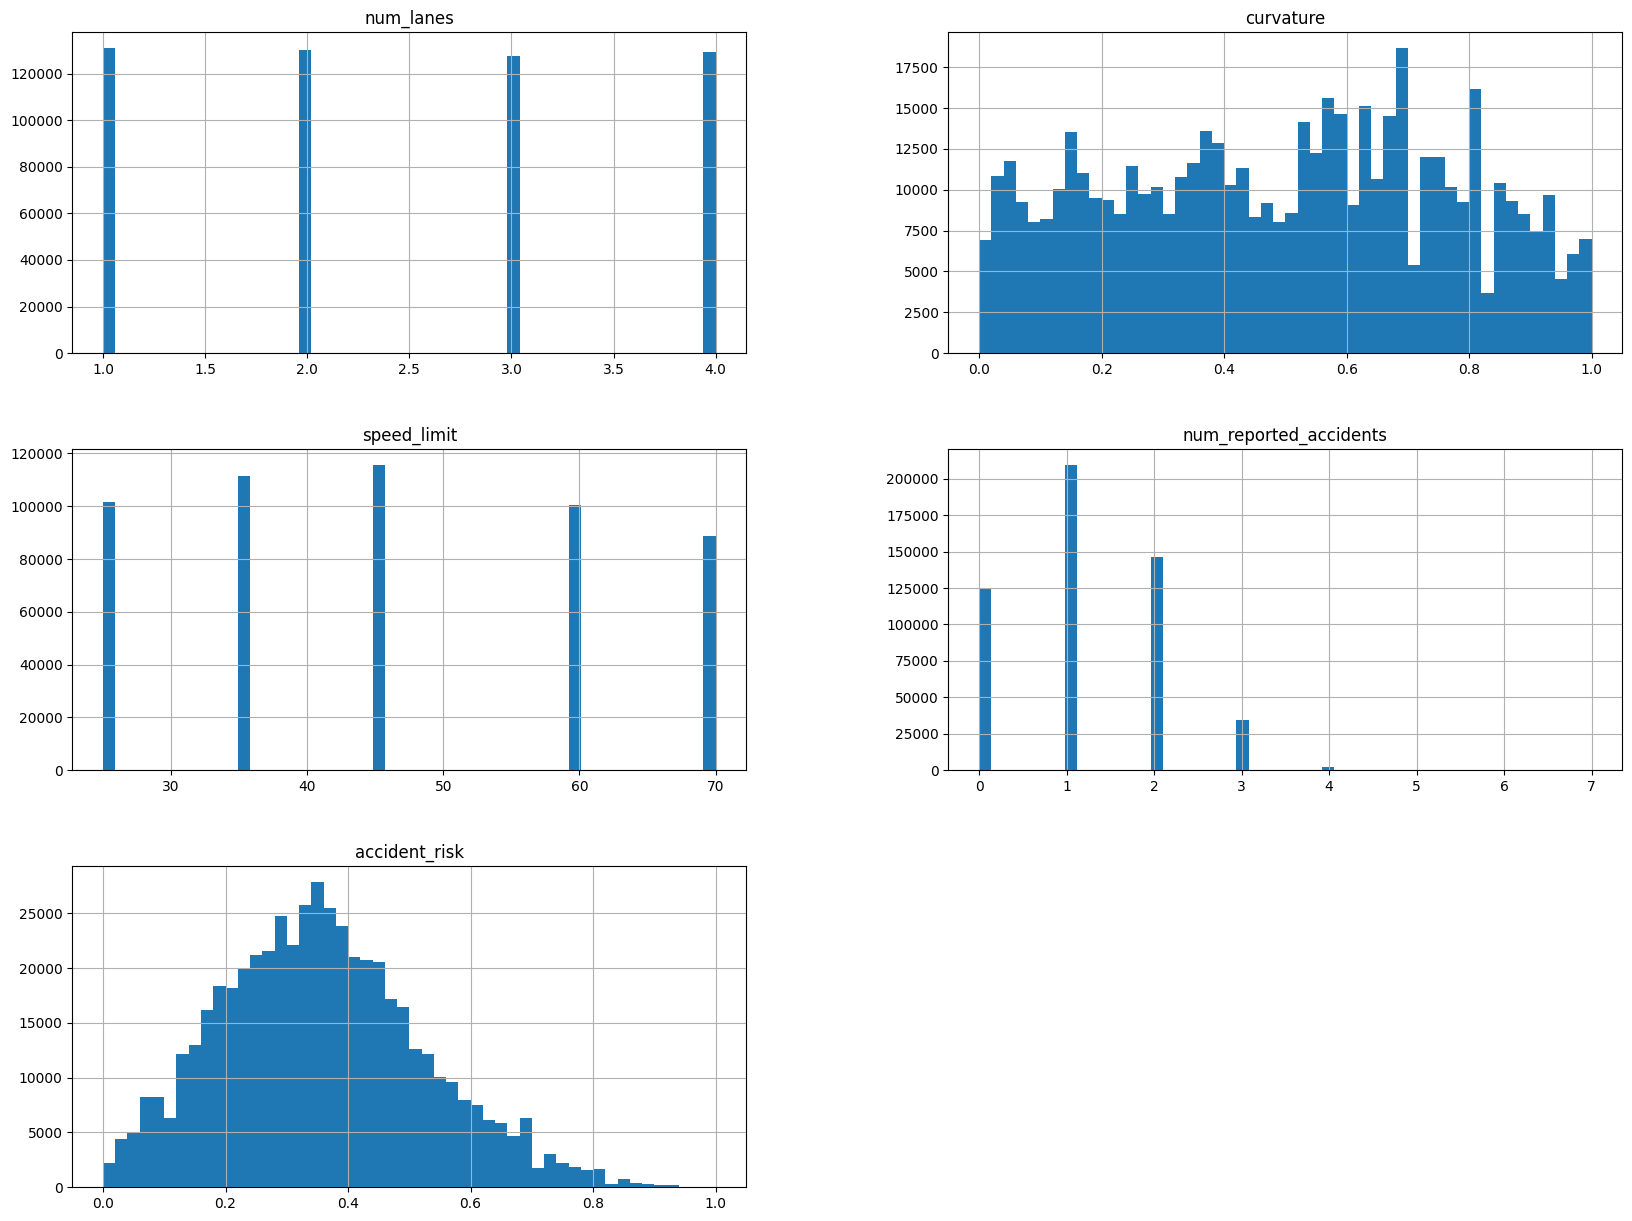

In [8]:
# call the hist() method on the whole dataset, and it will plot a histogram for each numerical attribute
X_full.hist(bins=50, figsize=(20,15))
plt.show()

In [9]:
# Remove rows with missing target and separate target from predictors

# If there were any rows with missing a missing target value, this line would remove all 'rows' (axis=0) from X_full that have missing values in the accident_risk column, and update the DataFrame directly.
# X_full.dropna(axis=0, subset=['accident_risk'], inplace=True)

In [10]:
# creating a copy of the full training data so we can play around with it later
road_accident = X_full.copy()

# assigning data to X and y
y = X_full.accident_risk
X_full.drop(['accident_risk'], axis=1, inplace=True)

# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X_full, y,
                                                      train_size=0.8, test_size=0.2,
                                                      random_state=42)

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_cols = [cname for cname in X_train_full.columns if
                    X_train_full[cname].nunique() < 10 and
                    X_train_full[cname].dtype == "str"]

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if
                  X_train_full[cname].dtype in ["int64", "float64", "bool"]]

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()

In [11]:
X_train.head()

,road_type,lighting,weather,time_of_day,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents
id,,,,,,,,,,,,
143159,rural,dim,clear,afternoon,2,0.43,60,False,False,True,True,2
20172,highway,night,clear,afternoon,4,0.18,25,False,False,True,False,1
57926,urban,night,clear,morning,1,0.20,70,False,True,True,True,1
193319,urban,daylight,foggy,evening,3,0.81,60,True,False,True,True,1
213938,rural,night,rainy,morning,3,0.43,35,False,True,True,True,2


<Axes: xlabel='curvature', ylabel='num_reported_accidents'>

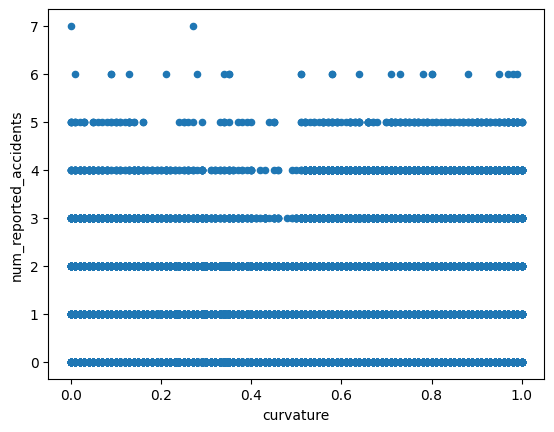

In [12]:
# relationship between curvature of road and num accidents
road_accident.plot(kind="scatter", x="curvature", y="num_reported_accidents")

In [13]:
corr_matrix = road_accident.corr(numeric_only=True)

In [14]:
# how much each numerical attribute correlates with accident risk
corr_matrix["accident_risk"].sort_values(ascending=False)

accident_risk             1.000000
curvature                 0.543946
speed_limit               0.430898
num_reported_accidents    0.213891
holiday                   0.051129
public_road               0.031032
road_signs_present        0.000629
school_season            -0.000977
num_lanes                -0.006003
Name: accident_risk, dtype: float64

array([[<Axes: xlabel='accident_risk', ylabel='accident_risk'>,
        <Axes: xlabel='curvature', ylabel='accident_risk'>,
        <Axes: xlabel='speed_limit', ylabel='accident_risk'>],
       [<Axes: xlabel='accident_risk', ylabel='curvature'>,
        <Axes: xlabel='curvature', ylabel='curvature'>,
        <Axes: xlabel='speed_limit', ylabel='curvature'>],
       [<Axes: xlabel='accident_risk', ylabel='speed_limit'>,
        <Axes: xlabel='curvature', ylabel='speed_limit'>,
        <Axes: xlabel='speed_limit', ylabel='speed_limit'>]], dtype=object)

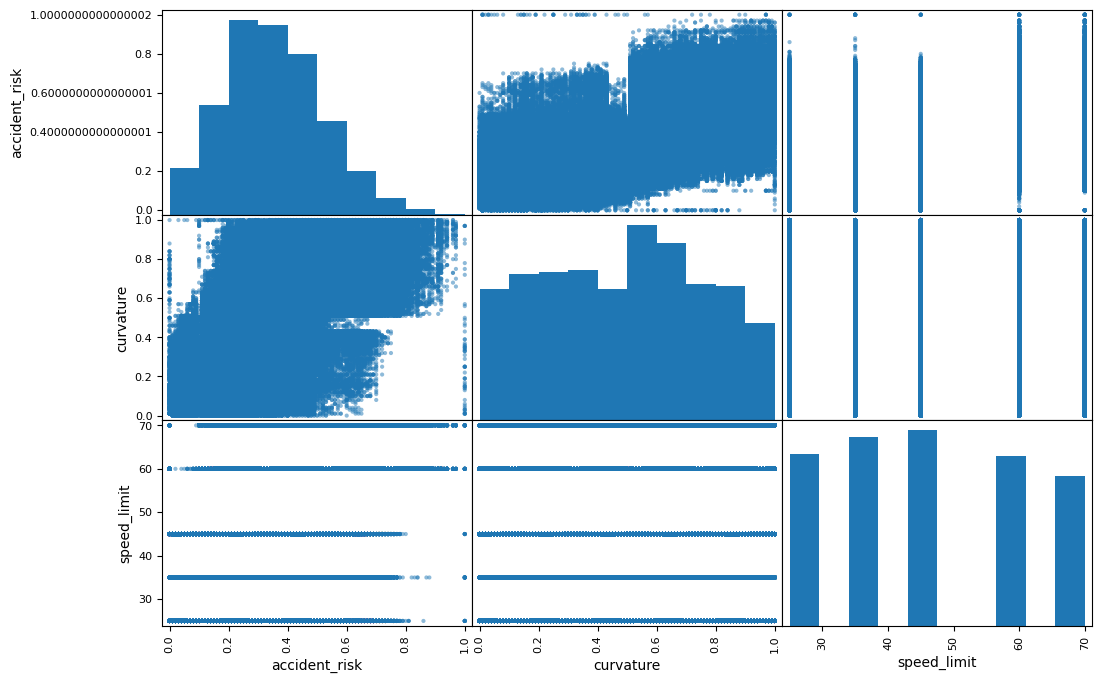

In [15]:
# The scatter_matrix() function plots every numerical attribute against every other numerical attribute
# However, we can focus on a few promising attributes that seem most correlated with accident risk instead
from pandas.plotting import scatter_matrix

attributes = ["accident_risk", "curvature", "speed_limit"]

scatter_matrix(road_accident[attributes], figsize=(12, 8))

In [17]:
# Obtain a list of all of the categorical variables in the training data

# First create a boolean Series (True/False) showing which columns in road_accident have data type 'str'
s = (X_train.dtypes == 'str')
print(s)

road_type                  True
lighting                   True
weather                    True
time_of_day                True
num_lanes                 False
curvature                 False
speed_limit               False
road_signs_present        False
public_road               False
holiday                   False
school_season             False
num_reported_accidents    False
dtype: bool


In [18]:
# s[s].index returns the index labels of all elements in 's' that are True, using the Series as its own filter.
cat_cols = list(s[s].index)

print("Categorical variables:")
print(cat_cols)

Categorical variables:
['road_type', 'lighting', 'weather', 'time_of_day']


In [19]:
# Count how many unique values each categorical column has and sort the columns from lowest to highest number of unique entries
# This is to help us decide whether we want to drop any categorical columns and which encoder to use
d = {}
for col in cat_cols:
    # .nunique() counts distinct values in a column
    d[col] = X_train[col].nunique()

# Sort by the second value (the count)
# x[0] = column name
# x[1] = number of unique values
sorted(d.items(), key=lambda x: x[1])

[('road_type', 3), ('lighting', 3), ('weather', 3), ('time_of_day', 3)]

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Preprocessing for numerical data - use strategy = median to be on safe side, as this won't distort data much 
# and in the event of any missing data, it won't cause the model to error/ behave unpredicatably
numerical_transformer = SimpleImputer(strategy='median')

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

## Code superseded and replaced by function below instead    
## Define model - note: the default value for n_estimators (trees) in this model is 100
# model = RandomForestRegressor(n_estimators=100, random_state=42) 

## Bundle preprocessing and modeling code in a pipeline
# clf = Pipeline(steps=[('preprocessor', preprocessor),
#                       ('model', model)
#                      ])

# Create a function so we can pass in models and the number of estimators we want to use
def classifier(model, n_estimators=100):

    # Define model
    model = model(n_estimators=n_estimators, random_state=42)

    # Bundle preprocessing and modeling code in a pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)
                         ])
    return clf

# Define model
clf = classifier(RandomForestRegressor)

# Preprocessing of training data, fit model
clf.fit(X_train, y_train)

# Preprocessing of validation data, get predictions
predictions = clf.predict(X_valid)

print('MAE:', mean_absolute_error(y_valid, predictions))

MAE: 0.04609554429430108


In [21]:
# Check for overfitting/ underfitting/ generalisation performance by comparing training prediction error to validation prediction error
train_predictions = clf.predict(X_train)
train_mae = mean_absolute_error(y_train, train_predictions)

# As we can see we have a slightly lower error on the training data,
# which indicates that the model has slightly overfit on the training data by being around 2.6x worse on validation
# we can try to improve the model further to close the gap in the scores/ be around the same
print("Train MAE:", train_mae)

Train MAE: 0.017493001661853917


In [22]:
# Baseline comparison - This code builds a simple baseline model that always predicts the same value (the mean of y_train), so you can check whether your trained model actually performs better than a naive guess.
# A “dumb model”:“Ignore all features — just always predict the average.”

# Take the average of all training target values
baseline = y_train.mean()

# Create predictions for validation set:
# [baseline] → a list with one value
# * len(y_valid) → repeat it for every validation row
# The model predicts the same value for every input
baseline_preds = [baseline] * len(y_valid)

# “On average, how far are these constant predictions from the actual values?”
baseline_mae = mean_absolute_error(y_valid, baseline_preds)

# Key takeaway - Our model is substantially better than the baseline (~ 65% better)
print("Baseline MAE:", baseline_mae)

Baseline MAE: 0.13269335667745616


In [23]:
X_train.head()

,road_type,lighting,weather,time_of_day,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents
id,,,,,,,,,,,,
143159,rural,dim,clear,afternoon,2,0.43,60,False,False,True,True,2
20172,highway,night,clear,afternoon,4,0.18,25,False,False,True,False,1
57926,urban,night,clear,morning,1,0.20,70,False,True,True,True,1
193319,urban,daylight,foggy,evening,3,0.81,60,True,False,True,True,1
213938,rural,night,rainy,morning,3,0.43,35,False,True,True,True,2


In [25]:
# Perform cross validation

from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates a negative MAE
# Note we no longer need to keep track of separate training and validation sets when performing cross validation, so here we use X_full and y
scores = -1 * cross_val_score(clf, X_full, y,
                              cv=3,
                              scoring='neg_mean_absolute_error')

print("MAE scores:\n", scores)

print("Average MAE score (across experiments):\n", scores.mean())


MAE scores:
 [0.04609888 0.04604901 0.04604441]
Average MAE score (across experiments):
 0.046064102477677095


In [26]:
## install XGBoost
#!python -m pip install xgboost

In [27]:
# Train another model - XGBoost
from xgboost import XGBRegressor

# Define model - note we are overwriting our previous model in this line of code
# note: default value for n_estimators (trees) in this model is 100
clf = classifier(XGBRegressor)

# Preprocessing of training data, fit Model 
clf.fit(X_train, y_train)

# Preprocessing of validation data, get predictions
predictions = clf.predict(X_valid)

print("MAE:", mean_absolute_error(y_valid, predictions))

MAE: 0.043674007913274485


In [28]:
# # To check what the active model is run the following (the model step is named 'model' in our pipeline):
active_model = clf.named_steps['model']
print(active_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [29]:
# Grid Search - taking too long

# from sklearn.model_selection import GridSearchCV

# # As our model is defined as 'model' in our clf pipeline, we must reference the parameters with it,
# # hence model__n_estimators. This tells GridSearch to tune parameters of the model inside the pipeline
# # This param_grid tells scikit learn to evaluate all 3 x 4 = 12 combinations of n_estimators 
# # and max_features hyperparameter values specified in the dict
# param_grid = [
#     {'model__n_estimators': [100, 150, 200], 'model__max_features': [2, 4, 6, 8]},
#     ]

# grid_search = GridSearchCV(clf, param_grid, cv=3,
#                            scoring ='neg_mean_squared_error',
#                            return_train_score=True)

# grid_search.fit(X_full, y)

In [30]:
# grid_search.best_estimator_

In [31]:
# cvres = grid_search.cv_results_

# for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
#     print(np.sqrt(-mean_score), params)